# Simple Neural Network in Python using Tensorflow

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

## Steps  before creating a Neural Network (Preprocess the data)

In [3]:
# remove warnings
import warnings
warnings.filterwarnings('ignore')

# Load titanic dataset
titanic = sns.load_dataset('titanic')

# Preprocessing
# Droping rows with missing 'age' and 'embarked' values
titanic.dropna(subset=['age', 'embarked'], inplace=True)

# Converting categorical variables to dummy variables
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who', 'deck'], drop_first=True)

# Selecting features and target
X = titanic.drop(['survived', 'alive', 'embark_town', 'adult_male', 'alone'], axis=1)
y = titanic['survived']

# spliting the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardizing the data 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:
X_train.shape[1]

18

In [5]:
# Building the model
input_layer = tf.keras.layers.Dense(10, activation= 'relu', input_shape=(X_train.shape[1],)) # input layer
# hidden_layer = tf.keras.layers.Dense(10, activation = 'relu') # hidden layer
output_layer = tf.keras.layers.Dense(1, activation= 'sigmoid') # output layer

# combine the layers into a model
model = tf.keras.models.Sequential([input_layer,
                                    #hidden_layer,
                                    output_layer])

# compile the model 
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [6]:
# train the model
model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=1)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6924 - loss: 0.6271
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7135 - loss: 0.6060
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7258 - loss: 0.5883
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7346 - loss: 0.5713
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7364 - loss: 0.5574
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7346 - loss: 0.5450 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7417 - loss: 0.5338 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7452 - loss: 0.5234
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7504 - loss: 0.5139 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7522 - loss: 0.5060 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7522 - loss: 0.4978 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7540 - los

In [7]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')
print(f'Test Loss: {loss}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7832 - loss: 0.4802 
Test Accuracy: 0.7832167744636536
Test Loss: 0.48017749190330505


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2917 - loss: 0.9105 - val_accuracy: 0.3636 - val_loss: 0.8188
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3023 - loss: 0.8638 - val_accuracy: 0.3986 - val_loss: 0.7811
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3357 - loss: 0.8230 - val_accuracy: 0.4406 - val_loss: 0.7465
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3831 - loss: 0.7848 - val_accuracy: 0.4615 - val_loss: 0.7159
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4200 - loss: 0.7520 - val_accuracy: 0.4965 - val_loss: 0.6879
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4675 - loss: 0.7197 - val_accuracy: 0.5315 - val_loss: 0.6633
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5220 - loss: 0.6920 - val_accuracy: 0.5874 - val_loss: 0.6412
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5975 - loss: 0.6654 - val_accuracy: 0.6713 - val_loss:

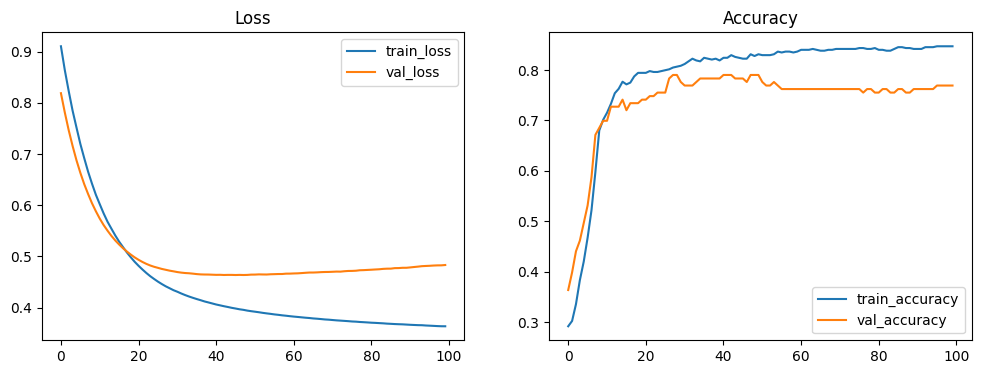

In [9]:
# Building the model
input_layer = tf.keras.layers.Dense(10, activation= 'relu', input_shape=(X_train.shape[1],)) # input layer
# hidden_layer = tf.keras.layers.Dense(10, activation = 'relu') # hidden layer
output_layer = tf.keras.layers.Dense(1, activation= 'sigmoid') # output layer

# combine the layers into a model
model = tf.keras.models.Sequential([input_layer,
                                    #hidden_layer,
                                    output_layer])

# compile the model (include accuracy metric so history contains it)
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

# train the model (use correct keyword validation_data)
history = model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=1, validation_data=(X_test, y_test))

# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')
print(f'Test Loss: {loss}')

# plotting the training and validation loss and accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
# accuracy key is 'accuracy' because we added it to compile
plt.plot(history.history['accuracy'], label='train_accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()